# Discrete Cosine Transform (DCT)

- **Author**: Neil Taison RIGAUD
- **St. ID**: 411221367

## Background

The Discrete Cosine Transform (DCT) helps separate the image into parts (or spectral sub-bands) of differing importance (with respect to the image's visual quality). The DCT is similar to the Discrete Fourier Transform (DFT): it transforms a signal or image from the spatial domain to the frequency domain.

## Assignment Description

We use the provided Lena gray (512 x 512) sample image as data.


1. Take the DCT Transform (Block size: 8 * 8)
2. Apply Quantization and Dequantization
3. Take the IDCT
4. Calculate the PSNR of $\hat{f}(x, y)$
5. Compute and display Error Image

## Environment Setup

### Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image
from IPython.display import display

### Constant Values

In [2]:
IMG_PATH = "data/lena_gray.png"
Q_TABLE = np.array(
    [
        [16, 11, 10, 16, 24, 40, 51, 61],
        [12, 12, 14, 19, 26, 58, 60, 55],
        [14, 13, 16, 24, 40, 57, 69, 56],
        [14, 17, 22, 29, 51, 87, 80, 62],
        [18, 22, 37, 56, 68, 109, 103, 77],
        [24, 35, 55, 64, 81, 104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99],
    ]
)

### Load and Open Image

We use the `Image` module from `PIL` to open the image and also convert to grayscale if not already done. Then we store the image pixel values as a numpy array. Finally display the image in the notebook.

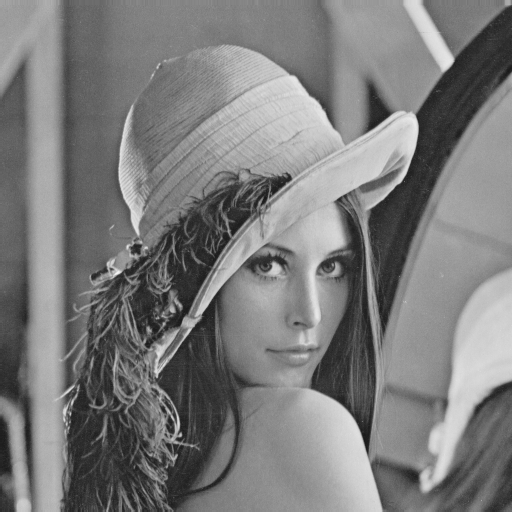

In [3]:
img = Image.open(IMG_PATH).convert("L")
img_arr = np.array(img).astype(np.float64)
display(img)

## Implementation

### Step 1: Take a DCT Tranform (Block 8*8)

We use the general equation for a 2D image ($N \times M$ image) DCT defined as:

$$
F(u,v) = \left(\frac{2}{N}\right)^{\!1/2}
       \left(\frac{2}{M}\right)^{\!1/2}
       \sum_{i=0}^{N-1}\sum_{j=0}^{M-1}
         \Lambda(i)\,\Lambda(j)\,
         \cos\!\left(\frac{\pi\,u(2i+1)}{2N}\right)
         \cos\!\left(\frac{\pi\,v(2j+1)}{2M}\right)
         f(i,j)
$$

where:

$$
\Lambda(\xi) =
\begin{cases}
\dfrac{1}{\sqrt{2}}, & \text{if } \xi = 0, \\
1, & \text{otherwise}.
\end{cases}
$$

In order to apply the DCT transform, we:

- Define a separate `_dct_basis()` function to compute the DCT basis matrix for any $n$ value according to the formula with default value $n = 8$.
- Pad the image to a multiple of the block size to prevent any error if the image dimension are not correct.
- Apply DCT to every block using matrix multiplications (`C @ block @ C.T`) which is a standard separable trick.
- Then we return a `float64` array containing the DCT coefficients where the padding has been removed.

In [4]:
def _dct_basis(n):
    """
    Return the n x n DCT-II basis matrix C such that for a block B:
        D = C @ B @ C.T
    Implements normalization consistent with:
        C[u,i] = sqrt(2/n) * alpha(u) * cos(pi * u * (2*i + 1) / (2*n))
    where alpha(0) = 1/sqrt(2), alpha(u>0) = 1.
    """
    u = np.arange(n)[:, None]  # shape (n,1)
    i = np.arange(n)[None, :]  # shape (1,n)
    alpha = np.ones((n, 1))
    alpha[0, 0] = 1.0 / np.sqrt(2.0)
    pref = np.sqrt(2.0 / n)
    angles = np.pi * u * (2 * i + 1) / (2.0 * n)
    C = pref * alpha * np.cos(angles)
    return C


def dct2_blockwise(img: np.ndarray, block_size: int = 8) -> np.ndarray:
    """
    Compute 2D DCT (block-wise) for a grayscale image.

    Parameters
    ----------
    img : np.ndarray
        2D grayscale image (H x W). dtype can be any numeric type.
    block_size : int
        Block size for DCT (default 8).

    Returns
    -------
    np.ndarray
        DCT coefficients array (float64) with same H x W shape as input.
    """
    if img.ndim != 2:
        raise ValueError("img must be a 2D grayscale array")

    H, W = img.shape
    n = block_size
    C = _dct_basis(n)

    # Pad to multiple of block size (use reflect padding to avoid edge artifacts)
    pad_h = (n - (H % n)) % n
    pad_w = (n - (W % n)) % n
    if pad_h or pad_w:
        img_padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode="reflect")
    else:
        img_padded = img.copy()

    Hp, Wp = img_padded.shape
    # Ensure float for computations
    img_padded = img_padded.astype(np.float64)

    # Output container
    dct_padded = np.zeros_like(img_padded, dtype=np.float64)

    # Process blocks
    for r in range(0, Hp, n):
        for c in range(0, Wp, n):
            block = img_padded[r : r + n, c : c + n]
            # block might be shape (n,n)
            D = C @ block @ C.T
            dct_padded[r : r + n, c : c + n] = D

    # Crop to original image size
    dct = dct_padded[:H, :W]
    return dct

[[ 1.28112500e+03  6.36332654e+00  2.50303196e+00 ... -2.91205575e+00
  -1.09559215e+01 -1.31880329e-01]
 [ 8.39230335e+00 -1.63499315e-02  4.75181453e-01 ... -6.11840383e+00
  -5.10159851e+00 -4.95160332e+00]
 [-5.29390137e+00 -9.60810158e-01 -1.39016504e+00 ...  2.70857101e+00
   1.21966991e+00  3.35892878e+00]
 ...
 [ 3.35142577e+00  7.46326621e-01  2.39866475e+00 ...  1.21149667e+00
  -7.79999080e-01 -1.91625442e+00]
 [-4.89961112e-01 -1.80665354e+00 -1.13128157e+00 ... -4.16270636e+00
   2.39492245e+00  1.74101131e+00]
 [ 2.35919764e+00 -1.34370502e+00 -2.30080975e+00 ... -5.74159072e+00
   7.38719504e-01  1.55666515e+00]]


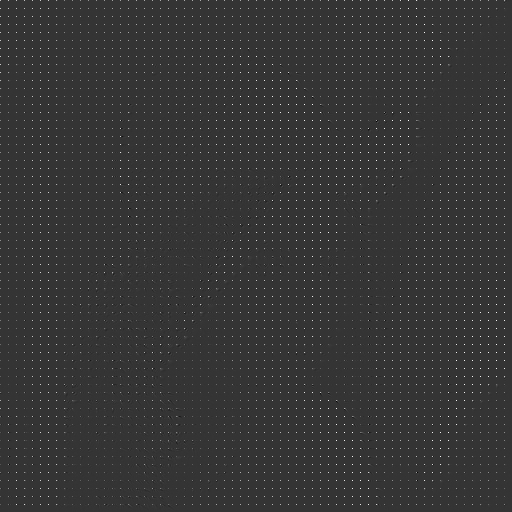

In [5]:
dct_img = dct2_blockwise(img_arr)


def norm_display_dct(dct_img: np.ndarray) -> np.ndarray:
    """Normalize a DCT output for image display"""

    # Normalize for display
    d_min, d_max = dct_img.min(), dct_img.max()
    dct_disp = 255 * (dct_img - d_min) / (d_max - d_min + 1e-9)

    return dct_disp.astype(np.uint8)


print(dct_img)
display(Image.fromarray(norm_display_dct(dct_img)))

### Step 2: Quantization and Dequantization

#### Quantization

We divide the obtained result from the DCT transform by the following Q table for quantization:

$$
Q =
\begin{bmatrix}
16 & 11 & 10 & 16 & 24 & 40 & 51 & 61 \\
12 & 12 & 14 & 19 & 26 & 58 & 60 & 55 \\
14 & 13 & 16 & 24 & 40 & 57 & 69 & 56 \\
14 & 17 & 22 & 29 & 51 & 87 & 80 & 62 \\
18 & 22 & 37 & 56 & 68 & 109 & 103 & 77 \\
24 & 35 & 55 & 64 & 81 & 104 & 113 & 92 \\
49 & 64 & 78 & 87 & 103 & 121 & 120 & 101 \\
72 & 92 & 95 & 98 & 112 & 100 & 103 & 99
\end{bmatrix}
$$

Since the image has a dimension far greater than the Q table, the division operation is performed in the following steps:

1. Reshape the image to break it into 8x8 blocks
2. Reorder the dimension to group the blocks together for broadcasting
3. Perform element-wise division by Q matrix and round to the nearest integer
4. Reshape back to the original image layout
5. Collapse into the original image

In [6]:
def quantize_image(dct_image, q_matrix=Q_TABLE):
    """
    Quantizes a DCT image using a quantization matrix Q.

    Args:
    dct_image (numpy.ndarray): The DCT coefficients of size (N, M).
                               N and M should be multiples of 8.
    q_matrix (numpy.ndarray): The 8x8 quantization matrix.

    Returns:
    numpy.ndarray: The quantized image.
    """
    h, w = dct_image.shape

    # Ensure the image dimensions are multiples of 8
    if h % 8 != 0 or w % 8 != 0:
        raise ValueError("Image dimensions must be multiples of 8.")

    # 1. Reshape the image to break it into 8x8 blocks.
    # New shape: (rows of blocks, block height, cols of blocks, block width)
    # Shape becomes: (h//8, 8, w//8, 8)
    blocks = dct_image.reshape(h // 8, 8, w // 8, 8)

    # 2. Reorder dimensions to group the blocks together for broadcasting.
    # New shape: (rows of blocks, cols of blocks, 8, 8)
    blocks = blocks.transpose(0, 2, 1, 3)

    # 3. Perform element-wise division by Q matrix and round to nearest integer.
    # NumPy broadcasts the (8, 8) Q matrix across the first two dimensions.
    quantized_blocks = np.round(blocks / q_matrix)

    # 4. Reshape back to the original image layout.
    # First, move the dimensions back: (rows of blocks, 8, cols of blocks, 8)
    quantized_blocks = quantized_blocks.transpose(0, 2, 1, 3)

    # Finally, collapse into the original (N, M) shape
    quantized_image = quantized_blocks.reshape(h, w)

    return quantized_image

[[80.  1.  0. ... -0. -0. -0.]
 [ 1. -0.  0. ... -0. -0. -0.]
 [-0. -0. -0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0. -0. -0.]
 [-0. -0. -0. ... -0.  0.  0.]
 [ 0. -0. -0. ... -0.  0.  0.]]


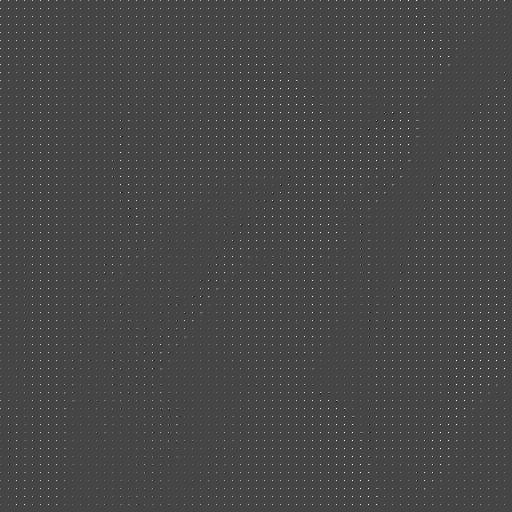

In [7]:
# Divide the DCT result
q_img = quantize_image(dct_img, Q_TABLE)
print(q_img)
display(Image.fromarray(norm_display_dct(q_img)))

#### Dequantization 

The dequantization of the image is performed by multiplying the previously obtained **quantized image** back with the same Q table.

We proceed to:
1. Reshape and transpose as done previously in the `quantize_image()` function
2. Perform element-wise **multiplication** by `Q_TABLE` matrix with no rounding this time.
3. Reshape the image back to original layout as done in the previous `quantize_image()` function.

In [8]:
def dequantize_image(quantized_image, q_matrix=Q_TABLE):
    """
    Dequantizes a quantized image by multiplication.
    """
    h, w = quantized_image.shape

    # Same reshaping and transposing as the quantization function
    # Shape becomes: (rows of blocks, cols of blocks, 8, 8)
    blocks = quantized_image.reshape(h // 8, 8, w // 8, 8).transpose(0, 2, 1, 3)

    # 1. Perform element-wise MULTIPLICATION by Q matrix (NO rounding)
    dequantized_blocks = blocks * q_matrix

    # Same reshaping back to original layout
    dequantized_blocks = dequantized_blocks.transpose(0, 2, 1, 3)
    dequantized_image = dequantized_blocks.reshape(h, w)

    return dequantized_image

[[1280.   11.    0. ...   -0.   -0.   -0.]
 [  12.   -0.    0. ...   -0.   -0.   -0.]
 [  -0.   -0.   -0. ...    0.    0.    0.]
 ...
 [   0.    0.    0. ...    0.   -0.   -0.]
 [  -0.   -0.   -0. ...   -0.    0.    0.]
 [   0.   -0.   -0. ...   -0.    0.    0.]]


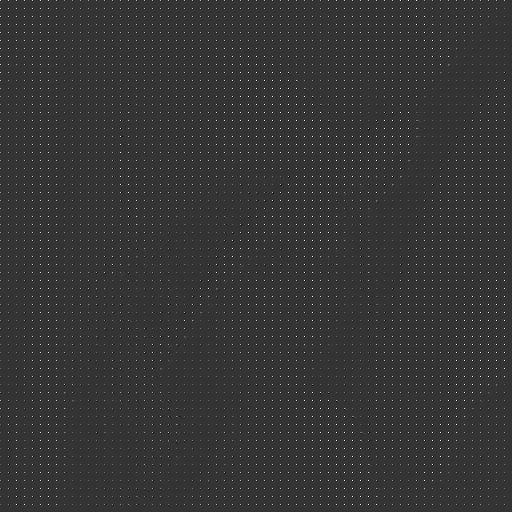

In [9]:
deq_img = dequantize_image(q_img)
print(deq_img)
display(Image.fromarray(norm_display_dct(deq_img)))

### Step 3: Take the IDCT

Here, we apply the Inverse Discrete Cosine Transform operation to the previously obtained dequantized image.

Since we have already implemented the normalized DCT basis function, the **inverse DCT (IDCT)** is achieved simply by swapping the roles of the basis matrix $C$ and its transpose $C^{T}$ in the transform equation.

Previously, we had the forward DCT defined as:

$$
D = CBC^{T}
$$

Because the $C$ matrix is **orthogonal**, its inverse is equal to its transpose: $C^{-1} = C^{T}$.

Thus, the inverse DCT (IDCT) is:

$$
B = C^{T}DC
$$

We implement the IDCT function by making two changes to the previous `dct2_blockwise()` function:

1. Change input name to `dct_coefficients` to reflect that the input is the frequency domain data.
2. Reverse the matrix multiplication order inside the loop: `C.T @ D @ C` instead of `C @ B @ C.T`.

In [10]:
# --- IDCT Implementation ---
def idct2_blockwise(dct_coefficients: np.ndarray, block_size: int = 8) -> np.ndarray:
    """
    Compute 2D IDCT (block-wise) for a DCT coefficients array.

    Parameters
    ----------
    dct_coefficients : np.ndarray
        2D DCT coefficients (H x W).
    block_size : int
        Block size for IDCT (default 8).

    Returns
    -------
    np.ndarray
        Reconstructed image array with same H x W shape as input.
    """
    if dct_coefficients.ndim != 2:
        raise ValueError("dct_coefficients must be a 2D array")

    H, W = dct_coefficients.shape
    n = block_size
    C = _dct_basis(n)

    # Pad if necessary (though usually the DCT array is already padded/sized correctly)
    pad_h = (n - (H % n)) % n
    pad_w = (n - (W % n)) % n
    if pad_h or pad_w:
        # Note: Padding should ideally be done before DCT, so if the input
        # is the result of your dct2_blockwise, it should already be padded
        # or the padding is 0. We'll use the input directly.
        idct_padded = np.pad(
            dct_coefficients, ((0, pad_h), (0, pad_w)), mode="constant"
        )
    else:
        idct_padded = dct_coefficients.copy()

    Hp, Wp = idct_padded.shape
    idct_padded = idct_padded.astype(np.float64)

    # Output container for the reconstructed image
    reconstructed_padded = np.zeros_like(idct_padded, dtype=np.float64)

    # Process blocks
    for r in range(0, Hp, n):
        for c in range(0, Wp, n):
            D = idct_padded[r : r + n, c : c + n]

            # Key step: IDCT = C.T @ D @ C
            B = C.T @ D @ C

            reconstructed_padded[r : r + n, c : c + n] = B

    # Crop back to the original image size
    reconstructed_image = reconstructed_padded[:H, :W]
    clipped_image = np.clip(reconstructed_image, 0, 255)

    return clipped_image

[[163 163 163 ... 177 157 128]
 [163 163 162 ... 170 151 123]
 [163 162 162 ... 169 152 127]
 ...
 [ 45  46  48 ...  99  97  96]
 [ 44  45  47 ... 101 101 101]
 [ 44  45  47 ... 103 105 106]]


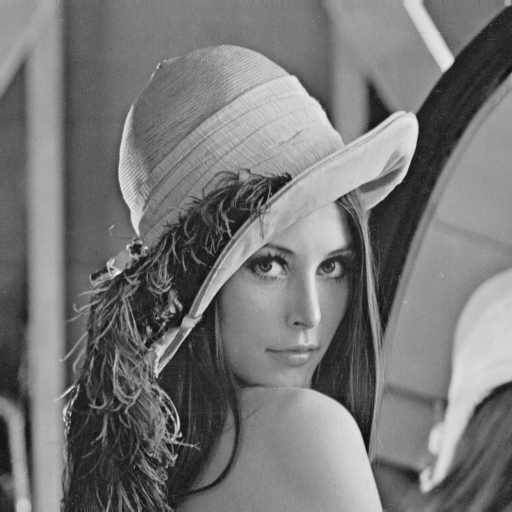

In [11]:
idct_img = idct2_blockwise(deq_img)
print(idct_img.astype(np.uint8))
display(Image.fromarray(norm_display_dct(idct_img)))

Without the quantization step, the image would be perfectly reconstructed.

### Step 4: Calculate the PSNR

The Peak Signal to Noise Ratio (PSNR) is defined as the ratio between the power of the signal and the power of the noise in an image, indicating the quality of the image with higher values representing better quality by reducing noise.

The PSNR is defined mathematically using the **Mean Squared Error (MSE)** for an image of size $M \times N$ as:

$$\text{MSE} = \frac{1}{M \cdot N} \sum_{i=1}^{M} \sum_{j=1}^{N} [\mathbf{I}_{\text{orig}}(i, j) - \mathbf{I}_{\text{rec}}(i, j)]^2$$

Where:
* $\mathbf{I}_{\text{orig}}$ is the **Original Image**.
* $\mathbf{I}_{\text{rec}}$ is the **Reconstructed Image**.
* $M$ and $N$ are the **height and width** of the images, respectively.

Thus, to calculate the PSNR, we proceed to:

1. Compute the **MSE**
2. Determine the maximum possible pixel value ($MAX$)
   - For a typical 8-bit grayscale image, this value is 255.
3. Compute the **PSNR** using the formula: $PSNR = 10 \times log_{10}\left(\frac{MAX^2}{MSE} \right)$

In [12]:
def calculate_mse(original_image: np.ndarray, reconstructed_image: np.ndarray) -> float:
    # Ensure both arrays have the same shape
    if original_image.shape != reconstructed_image.shape:
        raise ValueError("Images must have the same dimensions.")

    # Subtract the images, square the difference, and compute the mean
    mse = np.mean(
        (original_image.astype(np.float64) - reconstructed_image.astype(np.float64))
        ** 2
    )
    return mse


def calculate_psnr(
    original_image: np.ndarray,
    reconstructed_image: np.ndarray,
    max_pixel_value: int = 255,
) -> float:
    """
    Computes the Peak Signal-to-Noise Ratio (PSNR) between two images.
    """
    # 1. Calculate MSE
    mse = calculate_mse(original_image, reconstructed_image)

    if mse == 0:
        # If MSE is zero, the images are identical, and PSNR is infinite.
        # This is often returned as a very large number or infinity.
        return float("inf")

    # 2. Calculate PSNR
    # MAX_I**2 / MSE
    psnr = 10 * np.log10((max_pixel_value**2) / mse)

    return psnr

In [13]:
psnr_value = calculate_psnr(img_arr, idct_img)
print(f"PSNR: {psnr_value:.2f} dB")

PSNR: 35.83 dB


We obtained a **PSNR value of 35.83 dB** which indicates a better quality reconstruction along with less noise or distortion introduced by the compression (quantization) process since PSNR values ranging between 30 dB and 50 dB are considered good-quality image compression.

### Step 5: Compute and Display Error Image

We proceed to compute and display the absolute difference (error) image and display it.

In [14]:
def compute_and_display_error_image(
    original_image: np.ndarray, reconstructed_image: np.ndarray
):
    """
    Computes the absolute difference (error) image and prepares it for display.
    """
    # 1. Ensure inputs are float for accurate subtraction
    orig = original_image.astype(np.float64)
    rec = reconstructed_image.astype(np.float64)

    # 2. Compute the absolute difference
    error_image = np.abs(orig - rec)

    # Max error value in the image
    max_error = np.max(error_image)

    print(f"Maximum absolute error found: {max_error:.2f}")

    # Display the error image
    plt.figure(figsize=(6, 6))

    # Use 'gray' colormap for grayscale images.
    # The 'vmax' parameter ensures the colorscale max is the max error.
    plt.imshow(error_image, cmap="gray", vmin=0, vmax=max_error)

    plt.title("Error Image (|Original - Reconstructed|)")
    plt.colorbar(label="Absolute Pixel Difference")
    plt.axis("off")
    plt.show()

    return error_image

Maximum absolute error found: 40.92


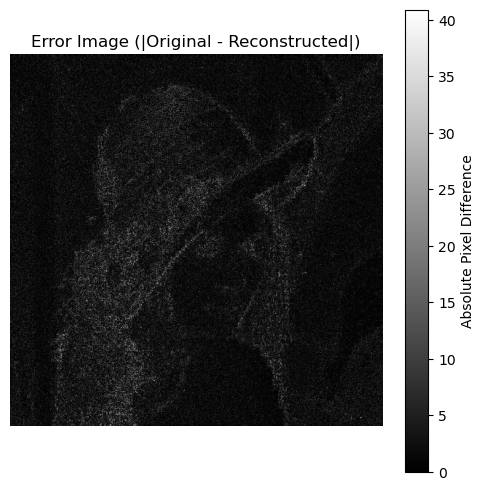

array([[1.98773956, 1.69738872, 1.16089034, ..., 8.03701404, 3.98528662,
        0.21227612],
       [1.67099319, 1.38064236, 0.84414397, ..., 1.36694014, 2.27060343,
        4.08063272],
       [1.08572222, 0.79537139, 0.25887301, ..., 0.82367597, 1.7447771 ,
        0.30095671],
       ...,
       [3.28107407, 4.52813348, 0.58237788, ..., 4.6616191 , 2.23987106,
        1.73734238],
       [1.6958031 , 2.94286252, 6.16764885, ..., 1.60567464, 3.29750365,
        5.38529733],
       [1.37905674, 2.62611615, 6.48439521, ..., 0.48660495, 0.20445358,
        0.84553823]], shape=(512, 512))

In [15]:
compute_and_display_error_image(img_arr, idct_img)

In this error image, the darker areas represent minimal error (0 -> black), and the brighter areas indicate where the quantization process caused the largest changes. We noticed that the largest errors occured around the sharp edges in the original image with a **maximum value of 40.92**.

## References

- [The Discrete Cosine Transform (DCT) - Cardiff University](https://users.cs.cf.ac.uk/Dave.Marshall/Multimedia/node231.html)
- [Peak Signal to Noise Ratio (PSNR)](https://www.sciencedirect.com/topics/computer-science/peak-signal-to-noise-ratio)